In [ ]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('dark_background')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
# Cell 2
# Dataset load karo
import os

# Absolute path use karo
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'paysim.csv'))

# Basic info
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Total Rows: 6,362,620
Total Columns: 11

Column Names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data Types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
# Cell 3 
# Missing values check karo
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# Fraud distribution
print("\n=== FRAUD DISTRIBUTION ===")
print(df['isFraud'].value_counts())
print(f"\nFraud %: {df['isFraud'].mean()*100:.4f}%")

# Transaction types
print("\n=== TRANSACTION TYPES ===")
print(df['type'].value_counts())

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== FRAUD DISTRIBUTION ===
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud %: 0.1291%

=== TRANSACTION TYPES ===
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


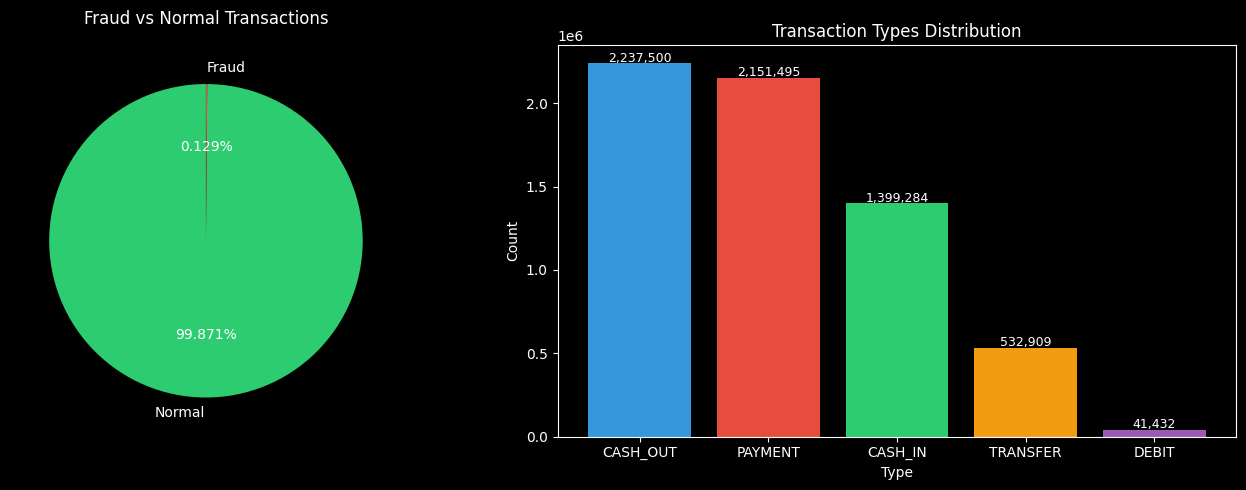


⚠️  Dataset highly imbalanced hai — 0.13% fraud only
✅ SMOTE ya class_weight use karenge model training mein


In [6]:
# Cell 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Fraud vs Normal
axes[0].pie(
    df['isFraud'].value_counts(),
    labels=['Normal', 'Fraud'],
    autopct='%1.3f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Fraud vs Normal Transactions', color='white', pad=15)

# Plot 2 — Transaction Types
type_counts = df['type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'])
axes[1].set_title('Transaction Types Distribution', color='white')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 10000, f'{v:,}', ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

print("\n⚠️  Dataset highly imbalanced hai — 0.13% fraud only")
print("✅ SMOTE ya class_weight use karenge model training mein")

=== FRAUD RATE BY TRANSACTION TYPE ===
          Fraud Count  Total Count  Fraud Rate %
type                                            
TRANSFER         4097       532909        0.7688
CASH_OUT         4116      2237500        0.1840
CASH_IN             0      1399284        0.0000
DEBIT               0        41432        0.0000
PAYMENT             0      2151495        0.0000


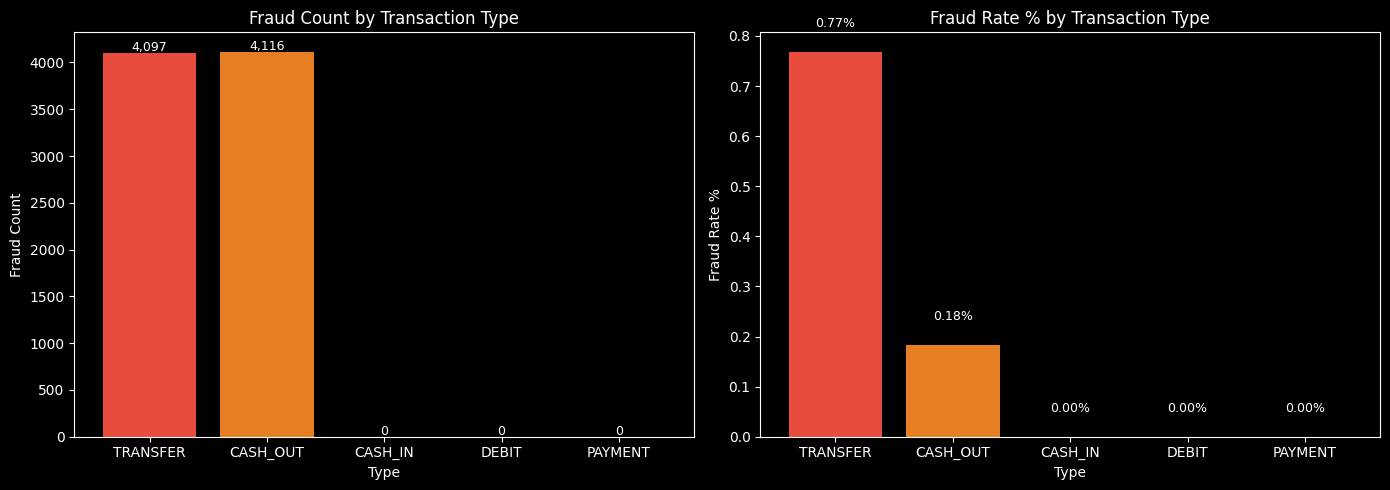

In [10]:
# Cell 5 
# Har transaction type mein fraud rate dekho
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
fraud_by_type.columns = ['Fraud Count', 'Total Count', 'Fraud Rate']
fraud_by_type['Fraud Rate %'] = fraud_by_type['Fraud Rate'] * 100
fraud_by_type = fraud_by_type.sort_values('Fraud Rate %', ascending=False)

print("=== FRAUD RATE BY TRANSACTION TYPE ===")
print(fraud_by_type[['Fraud Count', 'Total Count', 'Fraud Rate %']].round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Fraud Count per type
axes[0].bar(
    fraud_by_type.index,
    fraud_by_type['Fraud Count'],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
)
axes[0].set_title('Fraud Count by Transaction Type', color='white')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Fraud Count')
for i, v in enumerate(fraud_by_type['Fraud Count']):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', color='white', fontsize=9)

# Plot 2 — Fraud Rate % per type
axes[1].bar(
    fraud_by_type.index,
    fraud_by_type['Fraud Rate %'],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
)
axes[1].set_title('Fraud Rate % by Transaction Type', color='white')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Fraud Rate %')
for i, v in enumerate(fraud_by_type['Fraud Rate %']):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.show() 

=== FRAUD AMOUNT STATISTICS ===
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


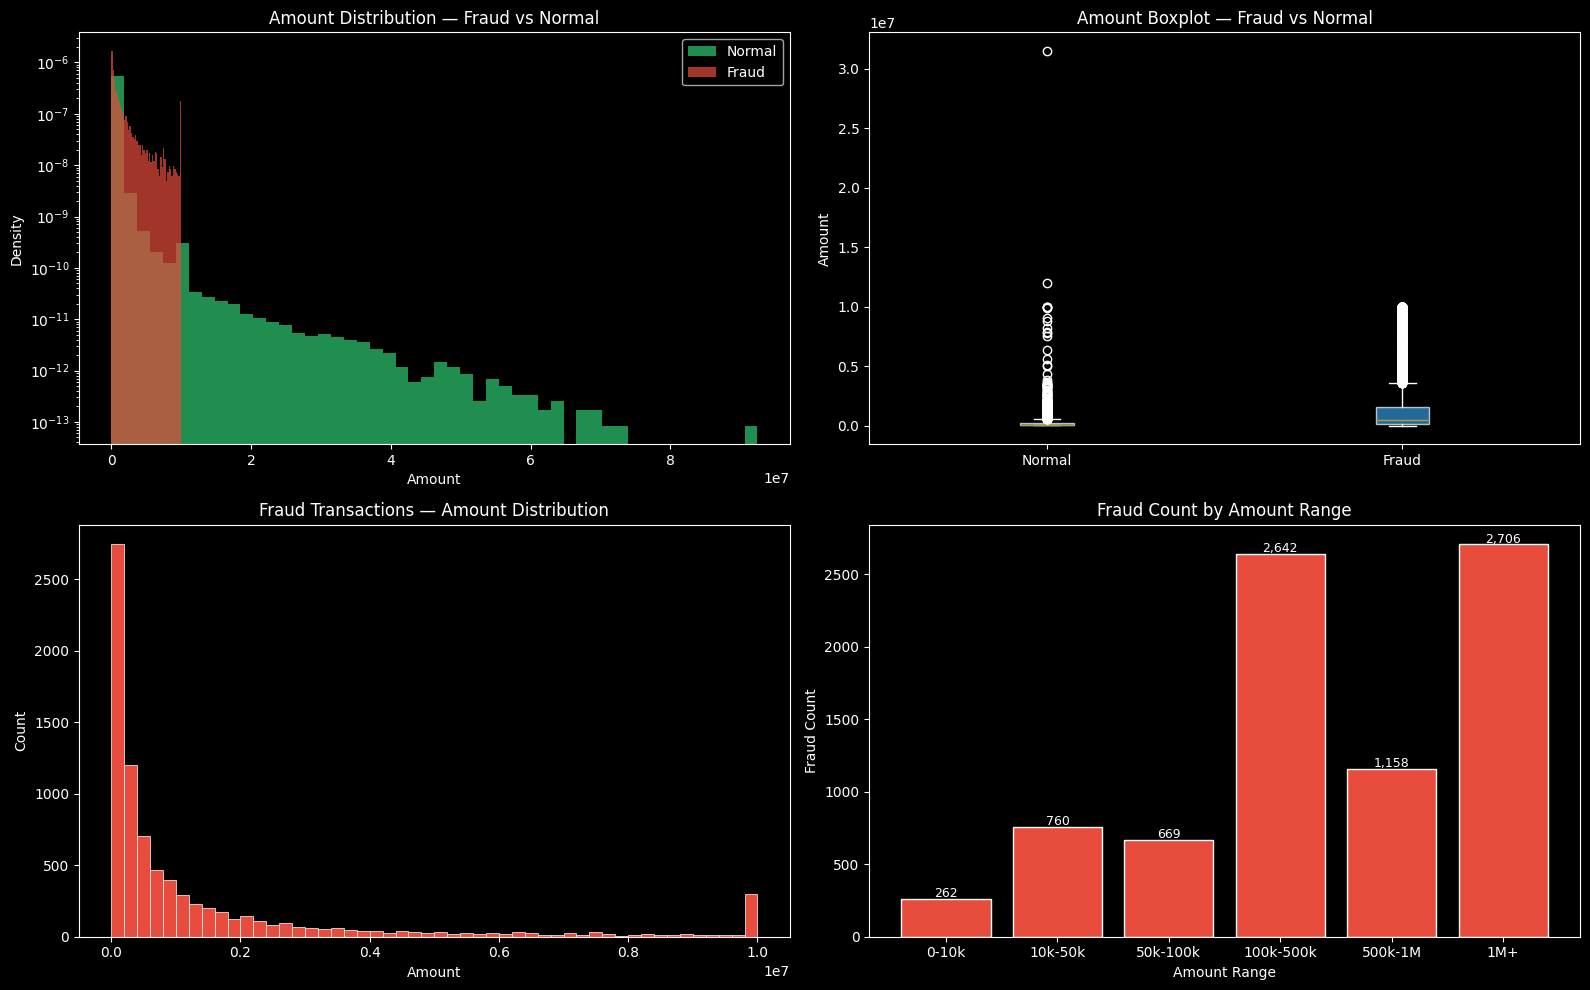

In [11]:
# Cell 6

# Amount distribution — Fraud vs Normal
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1 — Overall amount distribution (log scale)
# log scale isliye kyunki amounts bahut wide range mein hain
# 1 se lekar 10 million tak — normal scale pe graph readable nahi hoga
axes[0,0].hist(
    df[df['isFraud']==0]['amount'], 
    bins=50, 
    alpha=0.7, 
    color='#2ecc71', 
    label='Normal',
    density=True  # normalize karo percentage mein
)
axes[0,0].hist(
    df[df['isFraud']==1]['amount'], 
    bins=50, 
    alpha=0.7, 
    color='#e74c3c', 
    label='Fraud',
    density=True
)
axes[0,0].set_xlabel('Amount')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Amount Distribution — Fraud vs Normal', color='white')
axes[0,0].legend()
axes[0,0].set_yscale('log')  # log scale

# Plot 2 — Box plot — outliers dikhane ke liye
# Box plot = median, quartiles, aur outliers ek saath dikhata hai
fraud_amounts = df[df['isFraud']==1]['amount']
normal_sample = df[df['isFraud']==0]['amount'].sample(8213, random_state=42)
# sample isliye kyunki normal 63 lakh hain, fraud sirf 8213
# equal comparison ke liye same size sample liya

axes[0,1].boxplot(
    [normal_sample, fraud_amounts],
    labels=['Normal', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.7)
)
axes[0,1].set_title('Amount Boxplot — Fraud vs Normal', color='white')
axes[0,1].set_ylabel('Amount')

# Plot 3 — Fraud amount statistics
# Sirf fraud transactions ka amount breakdown
fraud_stats = df[df['isFraud']==1]['amount'].describe()
print("=== FRAUD AMOUNT STATISTICS ===")
print(fraud_stats)

axes[1,0].hist(
    fraud_amounts, 
    bins=50, 
    color='#e74c3c',
    edgecolor='white',
    linewidth=0.5
)
axes[1,0].set_title('Fraud Transactions — Amount Distribution', color='white')
axes[1,0].set_xlabel('Amount')
axes[1,0].set_ylabel('Count')

# Plot 4 — Amount ranges mein fraud count
# Kitne fraud kis range mein hain
bins = [0, 10000, 50000, 100000, 500000, 1000000, float('inf')]
labels_range = ['0-10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '1M+']
df['amount_range'] = pd.cut(df['amount'], bins=bins, labels=labels_range)

fraud_by_range = df[df['isFraud']==1]['amount_range'].value_counts().sort_index()
axes[1,1].bar(
    fraud_by_range.index, 
    fraud_by_range.values,
    color='#e74c3c',
    edgecolor='white'
)
axes[1,1].set_title('Fraud Count by Amount Range', color='white')
axes[1,1].set_xlabel('Amount Range')
axes[1,1].set_ylabel('Fraud Count')
for i, v in enumerate(fraud_by_range.values):
    axes[1,1].text(i, v + 10, f'{v:,}', ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# cell 7 
import pytz
import numpy as np
import random
random.seed(42)
np.random.seed(42)

print("=== INDIA CONTEXT MAPPING STARTING ===\n")

# =============================
# STEP 1 — step → Time Features
# =============================
# step % 24 = hour of day (0-23)
# step // 24 = day number
# day % 7 = day of week (0=Mon, 6=Sun)
# Yeh PaySim ke actual structure se 
# mathematically derived hai — random nahi

df['hour'] = df['step'] % 24
df['day'] = df['step'] // 24
df['day_of_week'] = df['day'] % 7
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_odd_hour'] = df['hour'].isin(range(0,6)).astype(int)

print("✅ STEP 1 DONE — Time features added")
print(f"Hour range: {df['hour'].min()} to {df['hour'].max()}")
print(f"Day range: {df['day'].min()} to {df['day'].max()}")
print(f"Weekend transactions: {df['is_weekend'].sum():,}")
print(f"Odd hour (2AM-6AM) transactions: {df['is_odd_hour'].sum():,}")

# =============================
# STEP 2 — type → Indian Types
# =============================
# PaySim African types → Indian banking types
# PAYMENT → UPI (small, instant payments)
# TRANSFER → NEFT (account to account)
# CASH_OUT → ATM_WITHDRAWAL
# CASH_IN → CASH_DEPOSIT
# DEBIT → NACH (auto-debit like EMI)

type_mapping = {
    'PAYMENT'  : 'UPI',
    'TRANSFER' : 'NEFT',
    'CASH_OUT' : 'ATM_WITHDRAWAL',
    'CASH_IN'  : 'CASH_DEPOSIT',
    'DEBIT'    : 'NACH'
}

df['txn_type_india'] = df['type'].map(type_mapping)

print("\n✅ STEP 2 DONE — Indian transaction types mapped")
print(df['txn_type_india'].value_counts())

# =============================
# STEP 3 — Amount → INR
# =============================
# African mobile money units → Indian Rupees
# Approximate conversion: 1 unit = ₹85
# (Based on USD/KES to INR rough equivalent)

INR_CONVERSION = 0.085

df['amount_inr'] = (df['amount'] * INR_CONVERSION).round(2)
df['oldbalance_inr'] = (df['oldbalanceOrg'] * INR_CONVERSION).round(2)
df['newbalance_inr'] = (df['newbalanceOrig'] * INR_CONVERSION).round(2)

print("\n✅ STEP 3 DONE — Amounts converted to INR")
print(f"Min amount: ₹{df['amount_inr'].min():,.0f}")
print(f"Max amount: ₹{df['amount_inr'].max():,.0f}")
print(f"Mean amount: ₹{df['amount_inr'].mean():,.0f}")

# =============================
# STEP 4 — RBI Thresholds
# =============================
# RBI ke 3 important thresholds —
#
# Structuring = deliberately keeping amounts
# just below ₹50,000 to avoid reporting
# Range: ₹40,000 - ₹49,999
#
# CTR = Cash Transaction Report
# RBI rule: ₹10 lakh+ cash = mandatory report
#
# RTGS = Real Time Gross Settlement
# Minimum: ₹2 lakh
# Large corporate/business transactions

df['is_structuring'] = (
    (df['amount_inr'] >= 40000) &
    (df['amount_inr'] <= 49999)
).astype(int)

df['is_ctr_threshold'] = (
    df['amount_inr'] >= 1000000
).astype(int)

df['is_rtgs_range'] = (
    df['amount_inr'] >= 200000
).astype(int)

print("\n✅ STEP 4 DONE — RBI thresholds added")
print(f"Structuring zone (₹40k-₹49,999): {df['is_structuring'].sum():,}")
print(f"CTR threshold (₹10L+): {df['is_ctr_threshold'].sum():,}")
print(f"RTGS range (₹2L+): {df['is_rtgs_range'].sum():,}")

# =============================
# STEP 5 — Account Types
# =============================
# India mein 5 major account types —
# Realistic distribution based on 
# RBI's actual account statistics
#
# Savings = 50% (most common)
# Current = 25% (business accounts)
# Student = 10% (college students)
# Jan Dhan = 10% (government scheme)
# Business = 5% (corporate)

account_types = ['savings', 'current', 'student', 'jan_dhan', 'business']
weights = [0.50, 0.25, 0.10, 0.10, 0.05]

df['account_type'] = np.random.choice(
    account_types,
    size=len(df),
    p=weights
)

print("\n✅ STEP 5 DONE — Account types added")
print(pd.Series(df['account_type']).value_counts())

# =============================
# STEP 6 — Balance Mismatch
# =============================
# Formula jo hona chahiye —
# oldbalanceOrg - amount = newbalanceOrig
#
# Agar yeh match nahi karta →
# Balance manipulation ho sakti hai
# Yeh ek powerful fraud signal hai
#
# abs() isliye kyunki difference
# positive ya negative dono ho sakta hai
# 0.01 tolerance isliye kyunki
# floating point calculations mein
# chhoti si rounding error normal hai

df['balance_mismatch'] = abs(
    (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']
).round(2)

df['has_mismatch'] = (df['balance_mismatch'] > 0.01).astype(int)

print("\n✅ STEP 6 DONE — Balance mismatch feature")
print(f"Transactions with mismatch: {df['has_mismatch'].sum():,}")
print(f"Fraud with mismatch: {df[df['isFraud']==1]['has_mismatch'].sum():,}")
print(f"Normal with mismatch: {df[df['isFraud']==0]['has_mismatch'].sum():,}")

# =============================
# STEP 7 — Save Clean Dataset
# =============================
# Sirf relevant columns rakhte hain
# Original PaySim columns + naye India columns

df_india = df[[
    'step', 'hour', 'day', 'day_of_week',
    'is_weekend', 'is_odd_hour',
    'type', 'txn_type_india',
    'amount', 'amount_inr',
    'nameOrig', 'oldbalance_inr', 'newbalance_inr',
    'nameDest', 'oldbalanceDest', 'newbalanceDest',
    'account_type',
    'is_structuring', 'is_ctr_threshold', 'is_rtgs_range',
    'balance_mismatch', 'has_mismatch',
    'isFraud', 'isFlaggedFraud'
]]

save_path = os.path.join(BASE_DIR, 'data', 'paysim_india.csv')
df_india.to_csv(save_path, index=False)

print(f"\n✅ STEP 7 DONE — Dataset saved!")
print(f"Location: {save_path}")
print(f"Shape: {df_india.shape}")
print(f"Total columns: {len(df_india.columns)}")
print(f"\nAll columns:")
for i, col in enumerate(df_india.columns, 1):
    print(f"  {i:2}. {col}")
print(f"\nSample (2 rows):")
df_india.head(2)


=== INDIA CONTEXT MAPPING STARTING ===

✅ STEP 1 DONE — Time features added
Hour range: 0 to 23
Day range: 0 to 30
Weekend transactions: 1,755,877
Odd hour (2AM-6AM) transactions: 112,605

✅ STEP 2 DONE — Indian transaction types mapped
txn_type_india
ATM_WITHDRAWAL    2237500
UPI               2151495
CASH_DEPOSIT      1399284
NEFT               532909
NACH                41432
Name: count, dtype: int64

✅ STEP 3 DONE — Amounts converted to INR
Min amount: ₹0
Max amount: ₹7,857,869
Mean amount: ₹15,288

✅ STEP 4 DONE — RBI thresholds added
Structuring zone (₹40k-₹49,999): 123,634
CTR threshold (₹10L+): 2,011
RTGS range (₹2L+): 33,795

✅ STEP 5 DONE — Account types added
account_type
savings     3181573
current     1591376
student      635978
jan_dhan     635478
business     318215
Name: count, dtype: int64

✅ STEP 6 DONE — Balance mismatch feature
Transactions with mismatch: 5,000,846
Fraud with mismatch: 45
Normal with mismatch: 5,000,801

✅ STEP 7 DONE — Dataset saved!
Location: c:\

,step,hour,day,day_of_week,is_weekend,is_odd_hour,type,txn_type_india,amount,amount_inr,...,oldbalanceDest,newbalanceDest,account_type,is_structuring,is_ctr_threshold,is_rtgs_range,balance_mismatch,has_mismatch,isFraud,isFlaggedFraud
0,1,1,0,0,0,1,PAYMENT,UPI,9839.64,836.37,...,0.0,0.0,savings,0,0,0,0.0,0,0,0
1,1,1,0,0,0,1,PAYMENT,UPI,1864.28,158.46,...,0.0,0.0,business,0,0,0,0.0,0,0,0


In [16]:
# Amount distribution check karo new values pe
print("=== NEW INR AMOUNT VERIFICATION ===")
print(f"Median: ₹{df_india['amount_inr'].median():,.0f}")
print(f"Mean: ₹{df_india['amount_inr'].mean():,.0f}")
print(f"Max: ₹{df_india['amount_inr'].max():,.0f}")
print(f"\nFraud transactions INR amounts:")
print(f"Fraud Median: ₹{df_india[df_india['isFraud']==1]['amount_inr'].median():,.0f}")
print(f"Fraud Mean: ₹{df_india[df_india['isFraud']==1]['amount_inr'].mean():,.0f}")
print(f"Fraud Max: ₹{df_india[df_india['isFraud']==1]['amount_inr'].max():,.0f}")

print(f"\n=== THRESHOLD VERIFICATION ===")
print(f"Structuring (₹40k-₹49,999): {df_india['is_structuring'].sum():,}")
print(f"CTR (₹10L+): {df_india['is_ctr_threshold'].sum():,}")
print(f"RTGS (₹2L+): {df_india['is_rtgs_range'].sum():,}")

=== NEW INR AMOUNT VERIFICATION ===
Median: ₹6,364
Mean: ₹15,288
Max: ₹7,857,869

Fraud transactions INR amounts:
Fraud Median: ₹37,521
Fraud Mean: ₹124,777
Fraud Max: ₹850,000

=== THRESHOLD VERIFICATION ===
Structuring (₹40k-₹49,999): 123,634
CTR (₹10L+): 2,011
RTGS (₹2L+): 33,795


In [17]:
# Cell 8 

import numpy as np
print("=== FEATURE ENGINEERING STARTING ===\n")

# Pehle paysim_india.csv load karo
# (Cell 7 mein save kiya tha)
df_feat = pd.read_csv(os.path.join(BASE_DIR, 'data', 'paysim_india.csv'))
print(f"Dataset loaded: {df_feat.shape}")

# =============================
# GROUP 1 — Amount Features
# =============================
# amount_log — log transform
# Kyunki amounts bahut skewed hain
# ₹100 se ₹78 lakh tak — log se normalize hoga
# np.log1p = log(1 + x) — 0 values handle karta hai
# log(0) = -infinity hota — log1p se bachte hain

df_feat['amount_log'] = np.log1p(df_feat['amount_inr'])

# amount_to_balance — kitna % balance gaya
# oldbalance_inr + 1 isliye ki division by zero na ho
# Agar balance 0 tha aur transaction hua = suspicious
df_feat['amount_to_balance'] = (
    df_feat['amount_inr'] / (df_feat['oldbalance_inr'] + 1)
).round(4)

# balance_after_zero — transaction ke baad balance 0?
# newbalance_inr = 0 matlab account completely drain
# Classic fraud pattern
df_feat['balance_after_zero'] = (
    df_feat['newbalance_inr'] == 0
).astype(int)

print("✅ GROUP 1 DONE — Amount features")
print(f"amount_log range: {df_feat['amount_log'].min():.2f} to {df_feat['amount_log'].max():.2f}")
print(f"amount_to_balance mean: {df_feat['amount_to_balance'].mean():.4f}")
print(f"balance_after_zero count: {df_feat['balance_after_zero'].sum():,}")

# =============================
# GROUP 2 — Sender Velocity
# =============================
# Har sender ke liye —
# Kitni transactions ki total?
# Kitna total amount bheja?
#
# groupby + transform = har row mein
# us sender ka aggregate value aata hai
#
# Example —
# Account A ne 5 transactions ki
# Har row jahan nameOrig = Account A
# sender_txn_count = 5 aayega

print("\nCalculating sender velocity (may take 30-60 sec)...")

sender_stats = df_feat.groupby('nameOrig').agg(
    sender_txn_count=('amount_inr', 'count'),
    sender_total_amount=('amount_inr', 'sum')
).reset_index()

# Merge back into main dataframe
df_feat = df_feat.merge(
    sender_stats,
    on='nameOrig',
    how='left'
)

print("✅ GROUP 2 DONE — Sender velocity features")
print(f"Max sender transactions: {df_feat['sender_txn_count'].max():,}")
print(f"Mean sender transactions: {df_feat['sender_txn_count'].mean():.2f}")
print(f"Fraud sender avg txn count: {df_feat[df_feat['isFraud']==1]['sender_txn_count'].mean():.2f}")
print(f"Normal sender avg txn count: {df_feat[df_feat['isFraud']==0]['sender_txn_count'].mean():.2f}")

# =============================
# GROUP 3 — Receiver Profile
# =============================
# Mule account detect karne ke liye —
# Receiver ne kitni baar receive kiya?
# Kitna total receive kiya?
#
# Mule account = bahut zyada receive karta hai
# different senders se — red flag

print("\nCalculating receiver profile...")

receiver_stats = df_feat.groupby('nameDest').agg(
    receiver_txn_count=('amount_inr', 'count'),
    receiver_total_amount=('amount_inr', 'sum')
).reset_index()

df_feat = df_feat.merge(
    receiver_stats,
    on='nameDest',
    how='left'
)

print("✅ GROUP 3 DONE — Receiver profile features")
print(f"Max receiver transactions: {df_feat['receiver_txn_count'].max():,}")
print(f"Mean receiver transactions: {df_feat['receiver_txn_count'].mean():.2f}")

# =============================
# GROUP 4 — Transaction Type Encoding
# =============================
# ML model strings nahi samajhta
# "UPI" → numbers mein convert karna padega
# One-Hot Encoding — har type ka alag column

# pd.get_dummies = automatic one-hot encoding
# prefix = column name prefix
# drop_first = True — multicollinearity avoid karne ke liye
# (5 types hain, 4 columns kaafi hain — 5th khud calculate hoti)

type_dummies = pd.get_dummies(
    df_feat['txn_type_india'],
    prefix='type',
    drop_first=False
).astype(int)

df_feat = pd.concat([df_feat, type_dummies], axis=1)

print("\n✅ GROUP 4 DONE — Transaction type encoding")
print("New columns:", type_dummies.columns.tolist())

# =============================
# GROUP 5 — Account Type Encoding
# =============================
# Same concept — account_type ko numbers mein

acct_dummies = pd.get_dummies(
    df_feat['account_type'],
    prefix='acct',
    drop_first=False
).astype(int)

df_feat = pd.concat([df_feat, acct_dummies], axis=1)

# Profile mismatch feature —
# Student ya Jan Dhan account se large amount = suspicious
# is_rtgs_range = 1 matlab ₹2L+ transaction
# Student/JanDhan ke liye yeh suspicious hai

df_feat['is_profile_mismatch'] = (
    (df_feat['account_type'].isin(['student', 'jan_dhan'])) &
    (df_feat['is_rtgs_range'] == 1)
).astype(int)

print("\n✅ GROUP 5 DONE — Account type encoding + profile mismatch")
print("New columns:", acct_dummies.columns.tolist())
print(f"Profile mismatch count: {df_feat['is_profile_mismatch'].sum():,}")
print(f"Profile mismatch in fraud: {df_feat[df_feat['isFraud']==1]['is_profile_mismatch'].sum():,}")

# =============================
# GROUP 6 — Final Feature Selection + Save
# =============================
# Sirf useful features rakhte hain
# nameOrig, nameDest = string IDs — model use nahi kar sakta
# step, day = time ke liye hour/day_of_week kaafi hai
# type, txn_type_india, account_type = encoded versions hain

feature_columns = [
    # Time features
    'hour', 'day_of_week', 'is_weekend', 'is_odd_hour',

    # Amount features
    'amount_inr', 'amount_log', 'amount_to_balance',
    'balance_after_zero',

    # Balance features
    'oldbalance_inr', 'newbalance_inr',
    'balance_mismatch', 'has_mismatch',

    # RBI threshold features
    'is_structuring', 'is_ctr_threshold', 'is_rtgs_range',

    # Velocity features
    'sender_txn_count', 'sender_total_amount',
    'receiver_txn_count', 'receiver_total_amount',

    # Encoded transaction types
    'type_ATM_WITHDRAWAL', 'type_CASH_DEPOSIT',
    'type_NACH', 'type_NEFT', 'type_UPI',

    # Encoded account types
    'acct_business', 'acct_current', 'acct_jan_dhan',
    'acct_savings', 'acct_student',

    # Domain knowledge features
    'is_profile_mismatch',

    # Target variable
    'isFraud'
]

df_model = df_feat[feature_columns].copy()

# Save karo
save_path = os.path.join(BASE_DIR, 'data', 'model_features.csv')
df_model.to_csv(save_path, index=False)

print("\n✅ GROUP 6 DONE — Final features selected + saved")
print(f"Location: {save_path}")
print(f"Final shape: {df_model.shape}")
print(f"\nTotal features: {len(feature_columns) - 1} (excluding target)")
print(f"\nFeature list:")
for i, col in enumerate([c for c in feature_columns if c != 'isFraud'], 1):
    print(f"  {i:2}. {col}")

print(f"\n=== FEATURE ENGINEERING COMPLETE ===")
print(f"Raw columns: 24 → Model features: {len(feature_columns)-1}")

=== FEATURE ENGINEERING STARTING ===

Dataset loaded: (6362620, 24)
✅ GROUP 1 DONE — Amount features
amount_log range: 0.00 to 15.88
amount_to_balance mean: 6054.3220
balance_after_zero count: 3,609,569

Calculating sender velocity (may take 30-60 sec)...
✅ GROUP 2 DONE — Sender velocity features
Max sender transactions: 3
Mean sender transactions: 1.00
Fraud sender avg txn count: 1.00
Normal sender avg txn count: 1.00

Calculating receiver profile...
✅ GROUP 3 DONE — Receiver profile features
Max receiver transactions: 113
Mean receiver transactions: 11.19

✅ GROUP 4 DONE — Transaction type encoding
New columns: ['type_ATM_WITHDRAWAL', 'type_CASH_DEPOSIT', 'type_NACH', 'type_NEFT', 'type_UPI']

✅ GROUP 5 DONE — Account type encoding + profile mismatch
New columns: ['acct_business', 'acct_current', 'acct_jan_dhan', 'acct_savings', 'acct_student']
Profile mismatch count: 6,853
Profile mismatch in fraud: 283

✅ GROUP 6 DONE — Final features selected + saved
Location: c:\Users\shivam pand